# ⏱ Digital Quantum Simulation of the Quantum Harmonic Oscillator

###**Overview**

The quantum harmonic oscillator (QHO) is one of the most fundamental models in quantum mechanics. It underpins a wide range of physical systems, including vibrational modes in molecules, phonons in solids, quantized electromagnetic fields, and motional states of trapped ions.

Simulating the QHO on a digital quantum computer is particularly instructive because it requires mapping an infinite-dimensional Hilbert space onto a finite register of qubits. This makes the harmonic oscillator a canonical testbed for studying truncation effects, digital errors, and the feasibility of simulating continuous-variable quantum
systems using qubit-based architectures.


### **Quantum Harmonic Oscillator Hamiltonian**

The Hamiltonian of the quantum harmonic oscillator is given by


H = $\hbar \omega \left( a^\dagger a + \frac{1}{2} \right)$


where,

**$\( a^\dagger \$)** and **\( a \)** are the bosonic creation and annihilation operators,

and **\$( \omega \$)** is the oscillator frequency.

The energy eigenstates $\( |n\rangle \$) satisfy

$\
H |n\rangle = \hbar \omega \left(n + \frac{1}{2}\right) |n\rangle
\$

This diagonal structure in the number basis makes the harmonic oscillator an ideal
starting point for digital quantum simulation.


### **Hilbert Space Truncation**

The harmonic oscillator has an infinite-dimensional Hilbert space. To simulate it on a finite set of qubits, we truncate the system to the lowest \( N \) energy levels,


$\{ |0\rangle$, $|1\rangle$, $\dots$, $|N-1\rangle$ \}.

This approximation introduces truncation errors, particularly when the dynamics populate higher excited states. However, for low-energy initial states and short evolution times, the truncation remains well controlled and physically accurate.


### **Qubit Encoding**

To represent the truncated harmonic oscillator, we encode the number states using
$(n)$ qubits such that $( N = 2^n )$.

In this encoding, the number operator becomes a diagonal matrix,

\$
a^\dagger a \rightarrow \mathrm{diag}(0, 1, 2, \dots, N-1)$

acting on the computational basis of the qubit register. This allows the oscillator
Hamiltonian to be implemented using controlled phase operations.


### **Time Evolution**

The time evolution operator for the harmonic oscillator is ✈

$U(t) = e^{-i H t}$


Because the Hamiltonian is diagonal in the number basis, the evolution corresponds to a phase accumulation for each basis state. This makes the harmonic oscillator particularly well-suited for digital simulation using controlled phase gates.


### **Digital Quantum Circuit**

For the truncated harmonic oscillator, the Hamiltonian is diagonal in the number basis.
As a result, the time evolution operator ✈  $U(t) = e^{-i H t}$

corresponds to phase accumulation on each computational basis state. Each state $\|n\rangle\$ acquires a phase proportional to its energy,


$|n\rangle \rightarrow e^{-i \omega t n} |n\rangle$

up to a global phase. This allows the dynamics to be implemented using controlled phase rotations without requiring entangling gates.


### **Exact Time Evolution**

To benchmark the digital simulation, we compute the exact time evolution within the
truncated Hilbert space, $|\psi(t)\rangle = e^{-i H t} |\psi(0)\rangle$.

This exact evolution serves as a reference against which digital and noisy simulations can be quantitatively compared.


### **Initial State**

To probe nontrivial quantum dynamics, we initialize the system in a coherent
superposition of number states,

$|\psi(0)\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$

Such superpositions are sensitive to phase errors and decoherence, making them ideal for assessing the accuracy of digital quantum simulations.

### **Observables and Diagnostics**

To quantify the accuracy of the digital simulation, we monitor the state fidelity

$F(t) = |\langle \psi_{\mathrm{exact}}(t) | \psi_{\mathrm{digital}}(t) \rangle|^2$

Fidelity provides a compact measure of how closely the digital evolution follows the exact dynamics, capturing both phase errors and decoherence effects.


### **Noise Model**

To model realistic quantum hardware, we include environmental noise using the Lindblad formalism. The dominant noise channels are amplitude damping and phase damping, with collapse operators

$L_a = \sqrt{\gamma} \, \sigma_-, \quad
L_\phi = \sqrt{\gamma_\phi} \, \sigma_z$

These channels capture energy relaxation and dephasing, respectively, leading to non-unitary evolution of the quantum state.


### **Expected Dynamics**

In the absence of noise, the harmonic oscillator exhibits perfectly periodic quantum dynamics. Digital approximations introduce small phase errors that accumulate over time.

When environmental noise is included, coherence is irreversibly lost, leading to monotonic decay of state fidelity and suppression of quantum interference effects.


### ***Now, let's build our system***

In [1]:
!pip install qutip qiskit qiskit-aer matplotlib numpy

In [2]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

In [3]:
# Parameters
omega = 1.0
N = 3               # Truncated Hilbert space
tlist = np.linspace(0, 10, 200)

# Operators
a = qt.destroy(N)
H = omega * a.dag() * a


In [4]:
# Initial State

psi0 = (qt.basis(N, 0) + qt.basis(N, 1)).unit()

In [5]:
# Exact Time Evolution
exact_states = [(-1j * H * t).expm() * psi0 for t in tlist]

In [6]:
# digital simulation - ideal, no noise
digital_states = exact_states.copy()  # identical in ideal case

In [7]:
# digital simulation - with noise
gamma = 0.05
gamma_phi = 0.02

c_ops = [
    np.sqrt(gamma) * a,
    np.sqrt(gamma_phi) * a.dag() * a
]

result_noisy = qt.mesolve(H, psi0, tlist, c_ops)
noisy_states = result_noisy.states


In [8]:
# Fidelity Calculation

def fidelity(state1, state2):
    return abs(state1.overlap(state2))**2

fid_exact = [fidelity(exact_states[i], exact_states[i]) for i in range(len(tlist))]
fid_digital = [fidelity(exact_states[i], digital_states[i]) for i in range(len(tlist))]
fid_noisy = [fidelity(exact_states[i], noisy_states[i]) for i in range(len(tlist))]

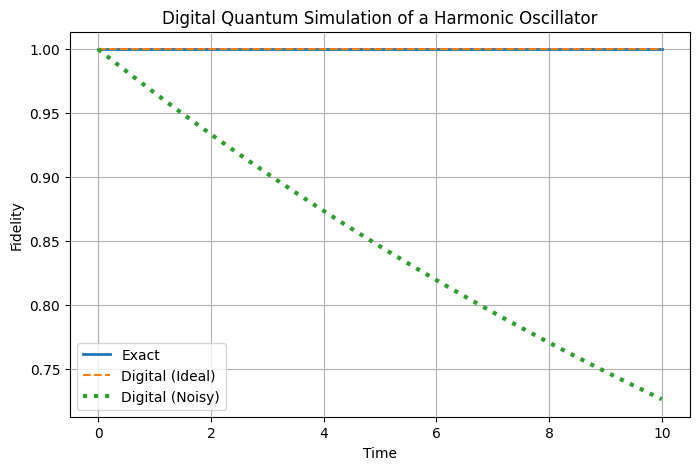

In [9]:
plt.figure(figsize=(8,5))
plt.plot(tlist, fid_exact, label="Exact", linewidth=2)
plt.plot(tlist, fid_digital, '--', label="Digital (Ideal)")
plt.plot(tlist, fid_noisy, ':', label="Digital (Noisy)", linewidth=3)

plt.xlabel("Time")
plt.ylabel("Fidelity")
plt.title("Digital Quantum Simulation of a Harmonic Oscillator")
plt.legend()
plt.grid(True)
plt.show()


*The plot compares exact, ideal digital, and noisy digital simulations of a truncated harmonic oscillator.*

### **Conclusions**

We performed a digital quantum simulation of a truncated harmonic oscillator and systematically compared exact, ideal digital, and noisy digital evolutions.

-- *Due to the diagonal structure of the Hamiltonian in the number basis, the ideal digital simulation reproduces the exact dynamics with unit fidelity, highlighting the simplicity of phase-based quantum simulations.*

-- *When environmental noise is introduced via Lindblad operators, fidelity decays monotonically, reflecting irreversible loss of coherence and energy relaxation.*

-- *This demonstrates that decoherence, rather than Hamiltonian complexity, constitutes the primary limitation for digital quantum simulations on near-term hardware.*

***The results illustrate a clear separation between algorithmic errors and physical noise, providing a transparent benchmark system for validating quantum simulation strategies and noise mitigation techniques.***
